In [1]:
first_name = "Benjamin"
last_name = "Branta"

# Import Packages
from io import StringIO

import pandas as pd
import requests
from bs4 import BeautifulSoup as bs

In [2]:
# Subtask 1.1: Requesting Web Page
url = "https://en.wikipedia.org/wiki/List_of_lakes_of_Western_Australia,_A%E2%80%93C"
response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})


In [ ]:
# Subtask 1.2: Turn HTML table into data frame
# Turn the HTML tables for all the lakes into one data frame named lakes_df with two columns: Name and Coordinates.

# Create the soup object
soup = bs(response.content, "lxml")

# find all tables with class wikitable
table_data = soup.find_all("table", {"class": "wikitable"})

# read HTML table into a list of dataframes
list_of_data_frames = pd.read_html(StringIO(str(table_data)), encoding="utf-8")

# convert list of dataframes into one dataframe named lakes_df
lakes_df = combined_df = pd.concat(list_of_data_frames, axis=0).reset_index(drop=True).drop('Remarks', axis=1)

# Subtask 1.3: Split coordinates in latitude and longitude
# Remove the \ufeff unicode character
lakes_df['Coordinates'] = lakes_df['Coordinates'].str.replace(u'\ufeff','')

# There are zero na rows and all rows have a '/'
# Create and add latitude and longitude columns
temp = lakes_df['Coordinates'].map(lambda s: s.split('/')[1])

lakes_df[['Latitude', 'Longitude']] = temp.str.split(expand=True)
lakes_df['Latitude'] = pd.to_numeric( lakes_df['Latitude'].map(lambda s: s.replace('°N','') if 'N' in s else "-"+s.replace('°S','')) )
lakes_df['Longitude'] = pd.to_numeric( lakes_df['Longitude'].map(lambda s: s.replace('°E','') if 'E' in s else "-"+s.replace('°W','')) )

assert lakes_df.shape[0] == 158

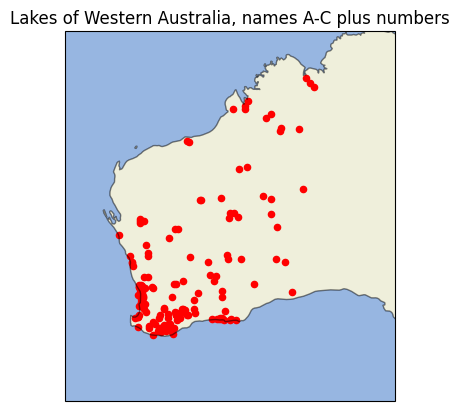

In [41]:
import matplotlib.pyplot as plt # for plotting, this is normal at this point
#initalize an axis
import cartopy.crs as ccrs
import cartopy.feature as cfeature

#I'll start by making a `fig,ax` pair, with a `projection` from the `cartopy` library.
# See [this documentation]() for more on projections in cartopy.
ax = plt.axes(projection=ccrs.PlateCarree()) # tell pyplot what projection to use, enabling later `add_feature` options.


#Set the `extent` of the map.  
#These are limits on the coordinates to plot.  
#I decided on my limits by eyeballing from [this map](https://www.mapsofworld.com/lat_long/europe.html)
# unit is degrees.  first is x0,x1, then is y0,y1
ax.set_extent([110,135,-40,-12], crs=ccrs.PlateCarree())  # you have to pass the `crs` argument to get the coordinates to match
ax.coastlines(alpha=0.5)

ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.25)

#plot points
lakes_df.plot(x="Longitude",y="Latitude",kind="scatter",title=f"Lakes of Western Australia, names A-C plus numbers", ax=ax,color='r')


# Save the plot by calling plt.savefig() BEFORE plt.show()
plt.savefig(f'{last_name}_{first_name}_assign7_task1-4.png',bbox_inches="tight",dpi=300)

plt.show() # rarely do this in .py scripts -- prefer to save to disk using `savefig`.

In [34]:
# Task 2: Tallest Buildings in the United States
# Subtask 2.1: Requesting Web Page
url_buildings = "https://en.wikipedia.org/wiki/List_of_tallest_buildings_in_the_United_States"
response_buildings = requests.get(url_buildings, headers={"User-Agent": "Mozilla/5.0"})

In [35]:
# Subtask 2.2: Turn HTML table into data frame
# Create the soup object
soup_buildings = bs(response_buildings.content, "lxml")

# Find 'Tallest Buildings' Heading then get the next table
# find all tables with class wikitable
table_data_buildings = soup_buildings.find("table", {"class": "wikitable"})

# read HTML table into a list of dataframes
list_of_data_frames_buildings = pd.read_html(StringIO(str(table_data_buildings)), encoding="utf-8")

# create buildings_df
buildings_df = list_of_data_frames_buildings[0].drop(['Image', 'Location', 'Notes'], axis=1)


In [36]:
# Subtask 2.3: Create numeric height variable
# drop ' †' from column 'Name' rows
buildings_df['Name'] = buildings_df['Name'].str.replace(' †','')

# Split on 'ft' and keep the first part
buildings_df['Height ft (m)'] = pd.to_numeric(buildings_df['Height ft (m)'].map(lambda s: s.split('ft')[0].strip().replace(',','')))
assert buildings_df.shape[0] == 102

In [38]:
# Subtask 2.4: Filter for buildings at least 1000 feet tall
buildings_1000_df = buildings_df[buildings_df['Height ft (m)'] >= 1000 ]
assert buildings_1000_df.shape[0] == 31



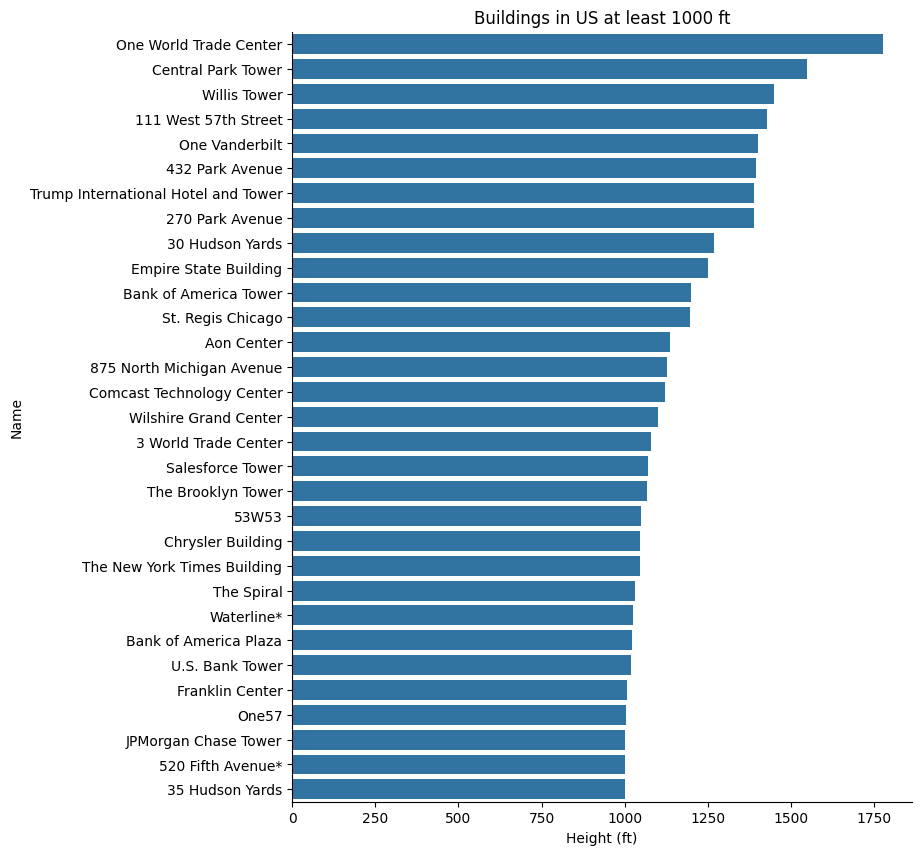

In [78]:
# Subtask 2.5: Graph the buildings
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 10))

sns.barplot(
    data=buildings_1000_df,
    y="Name",
    x="Height ft (m)",
    orient='h',
    ax=ax,
)
sns.despine()
ax.set_xlabel("Height (ft)")
ax.set_ylabel("Name")
ax.set_title("Buildings in US at least 1000 ft")
fig.savefig(
    f"{last_name}_{first_name}_assign7_task2-5.png",
    dpi=300,
    bbox_inches="tight",
)